# mmraz-probe-variations

Goal: inspect the temporal probe dataset and validate predictive-accuracy claims in this repo.

This notebook does three things:
1. Inspects the explicit/implicit temporal datasets used for probe analysis.
2. Evaluates the saved linear probes (`results/checkpoints/temporal_caa_layer_*.pkl`) on fresh GPT-2 activations.
3. Re-trains layer-wise logistic probes from scratch as an independent sanity check.

In [12]:
from pathlib import Path
import hashlib
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [13]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'pyproject.toml').exists() and (p / 'data').exists():
            return p
        p = p.parent
    raise RuntimeError('Could not locate repo root from current working directory.')

ROOT = find_repo_root(Path.cwd())
print('Repo root:', ROOT)

def pick_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('None of these paths exist: ' + str(paths))

explicit_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_caa.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_caa.json',
    ROOT / 'data/raw/temporal_scope_caa.json',
])
implicit_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_implicit.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_implicit.json',
    ROOT / 'data/raw/temporal_scope_implicit.json',
])
probe_dir = ROOT / 'results/checkpoints'

print('Explicit dataset:', explicit_path)
print('Implicit dataset:', implicit_path)
print('Probe directory:', probe_dir)

Repo root: /Users/michalmraz/code/spar-ai/temporal-awareness
Explicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_caa.json
Implicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_implicit.json
Probe directory: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints


In [14]:
def load_pairs(path: Path):
    data = json.loads(path.read_text())
    if isinstance(data, dict) and 'pairs' in data:
        return data.get('metadata', {}), data['pairs']
    return {}, data

exp_meta, explicit_pairs = load_pairs(explicit_path)
imp_meta, implicit_pairs = load_pairs(implicit_path)

print('Explicit metadata:', exp_meta)
print('Implicit metadata:', imp_meta)
print('\nCounts:')
print('  explicit pairs:', len(explicit_pairs))
print('  implicit pairs:', len(implicit_pairs))

# display(pd.DataFrame(explicit_pairs).head(3))
# display(pd.DataFrame(implicit_pairs).head(3))
display(pd.DataFrame(explicit_pairs))
display(pd.DataFrame(implicit_pairs))

Explicit metadata: {'dimension': 'temporal_scope', 'description': 'CAA-style contrastive pairs for temporal scope steering (immediate ↔ long-term)', 'style': 'caa_question_answer', 'n_pairs': 50, 'contrast': 'immediate/short-term vs long-term/future-oriented thinking', 'rationale': 'Follows actual CAA methodology with scenario-based questions and answer choices'}
Implicit metadata: {'dimension': 'temporal_scope', 'style': 'implicit_markers_only', 'description': 'Temporal scope dataset with NO explicit time words (minutes, years, etc.). Uses only semantic/contextual cues.', 'n_pairs': 50, 'validation': 'Strong test of semantic vs lexical encoding', 'created': '2025-01-26', 'position_randomized': True}

Counts:
  explicit pairs: 50
  implicit pairs: 50


,category,question,immediate,long_term
0,planning,"When deciding on a solution to this problem, y...",(A) What works right now to fix the immediate...,(B) What will create lasting value over the n...
1,planning,The best approach for this project is to:,(B) Get quick results and iterate as problems...,(A) Build a solid foundation that will scale ...
2,planning,"When allocating resources, you should prioritize:",(A) Addressing today's urgent needs,(B) Investing in tomorrow's opportunities
3,planning,"In making this decision, what matters most is:",(B) Solving the current crisis,(A) Preventing future problems
4,planning,The key factor to consider here is:,(A) What delivers immediate impact,(B) What compounds over time
5,decision_making,"When evaluating this option, you should ask:",(B) Does this solve today's problem?,(A) Will this still be valuable in 10 years?
6,decision_making,The most important outcome is:,(A) Getting quick wins now,(B) Building sustainable advantage
7,decision_making,Success means:,(B) Hitting this quarter's targets,(A) Creating generational impact
8,decision_making,The right choice is the one that:,(A) Provides instant gratification,(B) Yields delayed but greater rewards
9,decision_making,You should optimize for:,(B) Short-term gains,(A) Long-term value creation


,question,immediate,long_term,category
0,"When addressing this challenge, we should prio...",(A) Tactical responses that handle the situat...,(B) Strategic frameworks that create institut...,tactical_strategic
1,The most important consideration here is,(B) Operational efficiency and rapid execution,(A) Foundational principles and systemic resi...,operational_foundational
2,Our focus should be on,(A) Reactive measures to address presenting s...,(B) Proactive interventions that prevent root...,reactive_proactive
3,Success means,(B) Meeting deadlines and showing tangible pr...,(A) Building values and creating transformati...,deadlines_values
4,The right approach involves,(A) Triage and damage control,(B) Comprehensive planning and preventive mea...,emergency_preventive
5,We should optimize for,"(B) Speed, agility, and wins","(A) Sustainability, durability, and compound ...",speed_sustainability
6,The key metric is,(A) Direct throughput and output volume,(B) Cumulative impact and sustained performance,throughput_cumulative
7,Resource allocation should emphasize,(B) Firefighting and crisis response capacity,(A) Infrastructure development and capability...,firefighting_infrastructure
8,Decision-making should be guided by,(A) Responsiveness and decisiveness,(B) Reflection and thorough analysis,urgency_patience
9,The right mindset is,(B) Action-oriented and results-driven,(A) Vision-oriented and principle-driven,action_vision


In [15]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

reported_path = ROOT / 'results/probe_validation_results.json'
reported_hashes = {}
if reported_path.exists():
    reported = json.loads(reported_path.read_text())
    datasets = reported.get('datasets', {})
    reported_hashes['explicit'] = datasets.get('explicit_dataset', {}).get('sha256')
    reported_hashes['implicit'] = datasets.get('implicit_dataset', {}).get('sha256')

current_hashes = {
    'explicit': sha256(explicit_path),
    'implicit': sha256(implicit_path),
}

hash_df = pd.DataFrame([
    {
        'dataset': 'explicit',
        'current_sha256': current_hashes['explicit'],
        'reported_sha256': reported_hashes.get('explicit'),
        'match': current_hashes['explicit'] == reported_hashes.get('explicit'),
    },
    {
        'dataset': 'implicit',
        'current_sha256': current_hashes['implicit'],
        'reported_sha256': reported_hashes.get('implicit'),
        'match': current_hashes['implicit'] == reported_hashes.get('implicit'),
    },
])
display(hash_df)

if not hash_df['match'].all():
    print('NOTE: dataset hashes differ from the hashes recorded in results/probe_validation_results.json.')
    print('Exact numeric reproduction may differ if the dataset file has changed.')

,dataset,current_sha256,reported_sha256,match
0,explicit,1e782fe6304cbd7b3460a87bac1d4c78e72519a8aa4ad9...,8c30b3168b61cbce18623bdd6465cfe31ab7c5c54f309f...,False
1,implicit,9eeaec55cd10e2f72102c6758d0f6682f543aa2ce83591...,8d34212a4cb19f661bc30b1be31d5b691d72e5decbd496...,False


NOTE: dataset hashes differ from the hashes recorded in results/probe_validation_results.json.
Exact numeric reproduction may differ if the dataset file has changed.


In [16]:
def build_prompts_and_labels(pairs):
    prompts = []
    labels = []
    for pair in pairs:
        question = pair['question']
        immediate = pair['immediate']
        long_term = pair['long_term']

        prompts.append(question + '\n\nChoices:\n' + immediate)
        labels.append(0)

        prompts.append(question + '\n\nChoices:\n' + long_term)
        labels.append(1)

    return prompts, np.array(labels, dtype=np.int64)

explicit_prompts, y_exp = build_prompts_and_labels(explicit_pairs)
implicit_prompts, y_imp = build_prompts_and_labels(implicit_pairs)

print('Explicit samples:', len(y_exp), '| class balance:', np.bincount(y_exp))
print('Implicit samples:', len(y_imp), '| class balance:', np.bincount(y_imp))

Explicit samples: 100 | class balance: [50 50]
Implicit samples: 100 | class balance: [50 50]


In [17]:
MODEL_NAME = 'gpt2'
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()
n_layers = model.config.n_layer
print('Loaded', MODEL_NAME, '| n_layers =', n_layers, '| d_model =', model.config.n_embd)

Device: cpu
Loaded gpt2 | n_layers = 12 | d_model = 768


In [18]:
@torch.no_grad()
def extract_last_token_activations(prompts, batch_size=16):
    by_layer = {layer: [] for layer in range(n_layers)}

    for start in range(0, len(prompts), batch_size):
        batch = prompts[start:start + batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True, truncation=True).to(device)
        out = model(**enc, output_hidden_states=True)

        last_idx = enc['attention_mask'].sum(dim=1) - 1
        row_idx = torch.arange(last_idx.shape[0], device=device)

        # hidden_states[0] is embeddings, hidden_states[1]..[n_layers] are block outputs
        for layer in range(n_layers):
            hs = out.hidden_states[layer + 1]
            vecs = hs[row_idx, last_idx, :].detach().cpu().numpy()
            by_layer[layer].append(vecs)

    for layer in by_layer:
        by_layer[layer] = np.concatenate(by_layer[layer], axis=0)

    return by_layer

X_exp = extract_last_token_activations(explicit_prompts, batch_size=16)
X_imp = extract_last_token_activations(implicit_prompts, batch_size=16)

print('Activation shapes:')
print('  explicit layer 0:', X_exp[0].shape)
print('  implicit layer 0:', X_imp[0].shape)

Activation shapes:
  explicit layer 0: (100, 768)
  implicit layer 0: (100, 768)


In [19]:
probe_paths = {layer: probe_dir / f'temporal_caa_layer_{layer}_probe.pkl' for layer in range(n_layers)}
missing = [layer for layer, p in probe_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing probe files for layers: {missing}')

indices = np.arange(len(y_exp))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_exp)

rows = []
for layer in range(n_layers):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        probe = pickle.load(open(probe_paths[layer], 'rb'))

    rows.append({
        'layer': layer,
        'saved_probe_explicit_test_acc': probe.score(X_exp[layer][test_idx], y_exp[test_idx]),
        'saved_probe_explicit_full_acc': probe.score(X_exp[layer], y_exp),
        'saved_probe_implicit_acc': probe.score(X_imp[layer], y_imp),
    })

saved_eval_df = pd.DataFrame(rows).sort_values('layer').reset_index(drop=True)
display(saved_eval_df)

best_test = saved_eval_df.loc[saved_eval_df['saved_probe_explicit_test_acc'].idxmax()]
best_implicit = saved_eval_df.loc[saved_eval_df['saved_probe_implicit_acc'].idxmax()]
print('Best saved-probe explicit TEST layer:', int(best_test.layer), 'acc=', round(float(best_test.saved_probe_explicit_test_acc), 4))
print('Best saved-probe implicit layer:', int(best_implicit.layer), 'acc=', round(float(best_implicit.saved_probe_implicit_acc), 4))

,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc
0,0,0.80,0.96,0.68
1,1,0.75,0.95,0.69
2,2,0.75,0.95,0.70
3,3,0.80,0.96,0.65
4,4,0.80,0.96,0.63
5,5,0.75,0.95,0.67
6,6,0.80,0.96,0.66
7,7,0.80,0.96,0.70
8,8,0.75,0.95,0.67
9,9,0.85,0.97,0.71


Best saved-probe explicit TEST layer: 9 acc= 0.85
Best saved-probe implicit layer: 9 acc= 0.71


In [20]:
# Metric definitions used below:
# - explicit_test_acc: accuracy on the held-out 20% split from the explicit dataset
#   (train_idx/test_idx split of explicit samples only).
# - implicit_acc: accuracy on the full implicit dataset (a separate distribution,
#   not used for fitting), used as a generalization check.

def train_mm_probe(X_train, y_train):
    """Train mean-mass (difference-in-means) probe direction."""
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    direction = mu1 - mu0
    return direction


def mm_predict(X, direction):
    scores = X @ direction
    y_pred = (scores > 0).astype(np.int64)
    return y_pred, scores


def fit_whitener(X_train, reg=1e-2):
    """Fit training-only whitener with regularized covariance.

    Returns both:
    - precision (Sigma^{-1}) for Mahalanobis-style scoring
    - inv_sqrt (Sigma^{-1/2}) for whitening activations before LogisticRegression
    """
    mean_train = X_train.mean(axis=0)
    Xc = X_train - mean_train

    cov = np.cov(Xc, rowvar=False, bias=False)
    avg_var = float(np.trace(cov) / cov.shape[0]) if cov.shape[0] > 0 else 1.0
    cov_reg = cov + (reg * avg_var) * np.eye(cov.shape[0], dtype=cov.dtype)

    precision = np.linalg.pinv(cov_reg)

    eigvals, eigvecs = np.linalg.eigh(cov_reg)
    eigvals = np.clip(eigvals, 1e-12, None)
    inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    try:
        cond = float(np.linalg.cond(cov_reg))
    except Exception:
        cond = float('nan')

    return {
        'mean_train': mean_train,
        'cov': cov,
        'cov_reg': cov_reg,
        'precision': precision,
        'inv_sqrt': inv_sqrt,
        'reg': reg,
        'cov_reg_condition_number': cond,
    }


def apply_whitener(X, whitener):
    Xc = X - whitener['mean_train']
    return Xc @ whitener['inv_sqrt']


def train_whitened_mm_probe(X_train, y_train, reg=1e-2):
    """Train whitened MM probe.

    Score rule requested:
        score(x) = (x - mean_train)^T Sigma^{-1} (mu1 - mu0)
    predict class 1 if score > 0 else class 0.
    """
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    mm_direction = mu1 - mu0

    whitener = fit_whitener(X_train, reg=reg)
    effective_direction = whitener['precision'] @ mm_direction

    return {
        'mean_train': whitener['mean_train'],
        'mm_direction': mm_direction,
        'effective_direction': effective_direction,
        'precision': whitener['precision'],
        'cov_reg': whitener['cov_reg'],
        'reg': whitener['reg'],
        'cov_reg_condition_number': whitener['cov_reg_condition_number'],
    }


def whitened_mm_predict(X, model):
    Xc = X - model['mean_train']
    scores = Xc @ model['effective_direction']
    y_pred = (scores > 0).astype(np.int64)
    return y_pred, scores


retrain_rows = []
wlr_rows = []
mm_rows = []
wmm_rows = []
cosine_rows = []

whiten_reg = 1e-2

for layer in range(n_layers):
    X_train = X_exp[layer][train_idx]
    y_train = y_exp[train_idx]
    X_test = X_exp[layer][test_idx]
    y_test = y_exp[test_idx]

    # LogisticRegression probe (raw activations)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    retrain_rows.append({
        'layer': layer,
        'retrained_explicit_test_acc': clf.score(X_test, y_test),
        'retrained_implicit_acc': clf.score(X_imp[layer], y_imp),
    })

    # Whitened LogisticRegression probe (train+infer on whitened activations)
    whitener = fit_whitener(X_train, reg=whiten_reg)
    X_train_w = apply_whitener(X_train, whitener)
    X_test_w = apply_whitener(X_test, whitener)
    X_imp_w = apply_whitener(X_imp[layer], whitener)

    clf_w = LogisticRegression(max_iter=1000, random_state=42)
    clf_w.fit(X_train_w, y_train)
    wlr_rows.append({
        'layer': layer,
        'wlr_explicit_test_acc': clf_w.score(X_test_w, y_test),
        'wlr_implicit_acc': clf_w.score(X_imp_w, y_imp),
        'wlr_cov_reg_condition_number': whitener['cov_reg_condition_number'],
        'wlr_reg': float(whiten_reg),
    })

    # Mean-mass (difference-in-means) probe
    mm_direction = train_mm_probe(X_train, y_train)
    mm_pred_test, _ = mm_predict(X_test, mm_direction)
    mm_pred_implicit, _ = mm_predict(X_imp[layer], mm_direction)

    mm_rows.append({
        'layer': layer,
        'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
        'mm_implicit_acc': float((mm_pred_implicit == y_imp).mean()),
        'mm_direction_norm': float(np.linalg.norm(mm_direction)),
    })

    # Whitened MM probe
    wmm_model = train_whitened_mm_probe(X_train, y_train, reg=whiten_reg)
    wmm_pred_test, _ = whitened_mm_predict(X_test, wmm_model)
    wmm_pred_implicit, _ = whitened_mm_predict(X_imp[layer], wmm_model)

    wmm_rows.append({
        'layer': layer,
        'wmm_explicit_test_acc': float((wmm_pred_test == y_test).mean()),
        'wmm_implicit_acc': float((wmm_pred_implicit == y_imp).mean()),
        'wmm_effective_direction_norm': float(np.linalg.norm(wmm_model['effective_direction'])),
        'wmm_cov_reg_condition_number': wmm_model['cov_reg_condition_number'],
        'wmm_reg': float(whiten_reg),
    })

    # Geometry comparisons
    w_lr = clf.coef_.ravel()
    eff_dir = wmm_model['effective_direction']

    denom_mm = (np.linalg.norm(w_lr) * np.linalg.norm(mm_direction)) + 1e-12
    denom_wmm = (np.linalg.norm(w_lr) * np.linalg.norm(eff_dir)) + 1e-12
    cos_lr_vs_mm = float(np.dot(w_lr, mm_direction) / denom_mm)
    cos_lr_vs_wmm = float(np.dot(w_lr, eff_dir) / denom_wmm)

    cosine_rows.append({
        'layer': layer,
        'cosine_lr_vs_mm': cos_lr_vs_mm,
        'cosine_lr_vs_wmm': cos_lr_vs_wmm,
    })

retrain_df = pd.DataFrame(retrain_rows).sort_values('layer').reset_index(drop=True)
wlr_df = pd.DataFrame(wlr_rows).sort_values('layer').reset_index(drop=True)
mm_df = pd.DataFrame(mm_rows).sort_values('layer').reset_index(drop=True)
wmm_df = pd.DataFrame(wmm_rows).sort_values('layer').reset_index(drop=True)
cosine_df = pd.DataFrame(cosine_rows).sort_values('layer').reset_index(drop=True)

display(retrain_df)
display(wlr_df)
display(mm_df)
display(wmm_df)
display(cosine_df)

comparison = (
    saved_eval_df
    .merge(retrain_df, on='layer', how='inner')
    .merge(wlr_df[['layer', 'wlr_explicit_test_acc', 'wlr_implicit_acc']], on='layer', how='inner')
    .merge(mm_df[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']], on='layer', how='inner')
    .merge(wmm_df[['layer', 'wmm_explicit_test_acc', 'wmm_implicit_acc']], on='layer', how='inner')
)
display(comparison)

best_lr_exp = retrain_df.loc[retrain_df['retrained_explicit_test_acc'].idxmax()]
best_lr_imp = retrain_df.loc[retrain_df['retrained_implicit_acc'].idxmax()]
best_wlr_exp = wlr_df.loc[wlr_df['wlr_explicit_test_acc'].idxmax()]
best_wlr_imp = wlr_df.loc[wlr_df['wlr_implicit_acc'].idxmax()]
best_mm_exp = mm_df.loc[mm_df['mm_explicit_test_acc'].idxmax()]
best_mm_imp = mm_df.loc[mm_df['mm_implicit_acc'].idxmax()]
best_wmm_exp = wmm_df.loc[wmm_df['wmm_explicit_test_acc'].idxmax()]
best_wmm_imp = wmm_df.loc[wmm_df['wmm_implicit_acc'].idxmax()]

print('Best LR explicit TEST layer:', int(best_lr_exp.layer), 'acc=', round(float(best_lr_exp.retrained_explicit_test_acc), 4))
print('Best LR implicit layer:     ', int(best_lr_imp.layer), 'acc=', round(float(best_lr_imp.retrained_implicit_acc), 4))
print('Best WLR explicit TEST layer:', int(best_wlr_exp.layer), 'acc=', round(float(best_wlr_exp.wlr_explicit_test_acc), 4))
print('Best WLR implicit layer:     ', int(best_wlr_imp.layer), 'acc=', round(float(best_wlr_imp.wlr_implicit_acc), 4))
print('Best MM explicit TEST layer: ', int(best_mm_exp.layer), 'acc=', round(float(best_mm_exp.mm_explicit_test_acc), 4))
print('Best MM implicit layer:      ', int(best_mm_imp.layer), 'acc=', round(float(best_mm_imp.mm_implicit_acc), 4))
print('Best WMM explicit TEST layer:', int(best_wmm_exp.layer), 'acc=', round(float(best_wmm_exp.wmm_explicit_test_acc), 4))
print('Best WMM implicit layer:     ', int(best_wmm_imp.layer), 'acc=', round(float(best_wmm_imp.wmm_implicit_acc), 4))



,layer,retrained_explicit_test_acc,retrained_implicit_acc
0,0,0.80,0.68
1,1,0.70,0.72
2,2,0.75,0.70
3,3,0.85,0.72
4,4,0.85,0.67
5,5,0.75,0.65
6,6,0.75,0.68
7,7,0.80,0.70
8,8,0.75,0.75
9,9,0.75,0.76


,layer,wlr_explicit_test_acc,wlr_implicit_acc,wlr_cov_reg_condition_number,wlr_reg
0,0,0.65,0.60,6957.158721,0.01
1,1,0.75,0.62,6962.673277,0.01
2,2,0.65,0.70,6951.936236,0.01
3,3,0.80,0.67,6422.713339,0.01
4,4,0.80,0.61,6686.924841,0.01
5,5,0.80,0.62,6745.728616,0.01
6,6,0.85,0.64,6718.984055,0.01
7,7,0.85,0.68,6467.635134,0.01
8,8,0.80,0.66,6536.766106,0.01
9,9,0.75,0.69,6215.288456,0.01


,layer,mm_explicit_test_acc,mm_implicit_acc,mm_direction_norm
0,0,0.70,0.58,8.877615
1,1,0.70,0.67,10.010510
2,2,0.55,0.67,11.581745
3,3,0.55,0.59,13.504474
4,4,0.55,0.56,15.107958
5,5,0.50,0.60,16.429241
6,6,0.55,0.69,18.505970
7,7,0.55,0.67,20.285185
8,8,0.55,0.50,22.238438
9,9,0.50,0.56,24.579754


,layer,wmm_explicit_test_acc,wmm_implicit_acc,wmm_effective_direction_norm,wmm_cov_reg_condition_number,wmm_reg
0,0,0.65,0.66,1.707364,6957.158721,0.01
1,1,0.75,0.65,1.471593,6962.673277,0.01
2,2,0.65,0.69,0.927865,6951.936236,0.01
3,3,0.80,0.67,0.716926,6422.713339,0.01
4,4,0.80,0.62,0.555274,6686.924841,0.01
5,5,0.80,0.62,0.512963,6745.728616,0.01
6,6,0.85,0.64,0.468399,6718.984055,0.01
7,7,0.85,0.68,0.424346,6467.635134,0.01
8,8,0.80,0.66,0.366192,6536.766106,0.01
9,9,0.75,0.69,0.311450,6215.288456,0.01


,layer,cosine_lr_vs_mm,cosine_lr_vs_wmm
0,0,0.628678,0.808308
1,1,0.604909,0.845614
2,2,0.633265,0.901688
3,3,0.642953,0.923094
4,4,0.671175,0.936263
5,5,0.656529,0.938683
6,6,0.638878,0.944092
7,7,0.631695,0.935405
8,8,0.627342,0.943021
9,9,0.651713,0.955862


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc,retrained_explicit_test_acc,retrained_implicit_acc,wlr_explicit_test_acc,wlr_implicit_acc,mm_explicit_test_acc,mm_implicit_acc,wmm_explicit_test_acc,wmm_implicit_acc
0,0,0.80,0.96,0.68,0.80,0.68,0.65,0.60,0.70,0.58,0.65,0.66
1,1,0.75,0.95,0.69,0.70,0.72,0.75,0.62,0.70,0.67,0.75,0.65
2,2,0.75,0.95,0.70,0.75,0.70,0.65,0.70,0.55,0.67,0.65,0.69
3,3,0.80,0.96,0.65,0.85,0.72,0.80,0.67,0.55,0.59,0.80,0.67
4,4,0.80,0.96,0.63,0.85,0.67,0.80,0.61,0.55,0.56,0.80,0.62
5,5,0.75,0.95,0.67,0.75,0.65,0.80,0.62,0.50,0.60,0.80,0.62
6,6,0.80,0.96,0.66,0.75,0.68,0.85,0.64,0.55,0.69,0.85,0.64
7,7,0.80,0.96,0.70,0.80,0.70,0.85,0.68,0.55,0.67,0.85,0.68
8,8,0.75,0.95,0.67,0.75,0.75,0.80,0.66,0.55,0.50,0.80,0.66
9,9,0.85,0.97,0.71,0.75,0.76,0.75,0.69,0.50,0.56,0.75,0.69


Best LR explicit TEST layer: 3 acc= 0.85
Best LR implicit layer:      9 acc= 0.76
Best WLR explicit TEST layer: 6 acc= 0.85
Best WLR implicit layer:      10 acc= 0.73
Best MM explicit TEST layer:  0 acc= 0.7
Best MM implicit layer:       10 acc= 0.71
Best WMM explicit TEST layer: 6 acc= 0.85
Best WMM implicit layer:      10 acc= 0.73


Claimed (repo README):
  Layer 8 train/explicit peak ~ 0.925
  Layer 6 test/implicit ~ 0.84

Measured with saved probes on current dataset files:
  Layer 8 explicit test acc = 0.75
  Layer 6 implicit acc      = 0.66


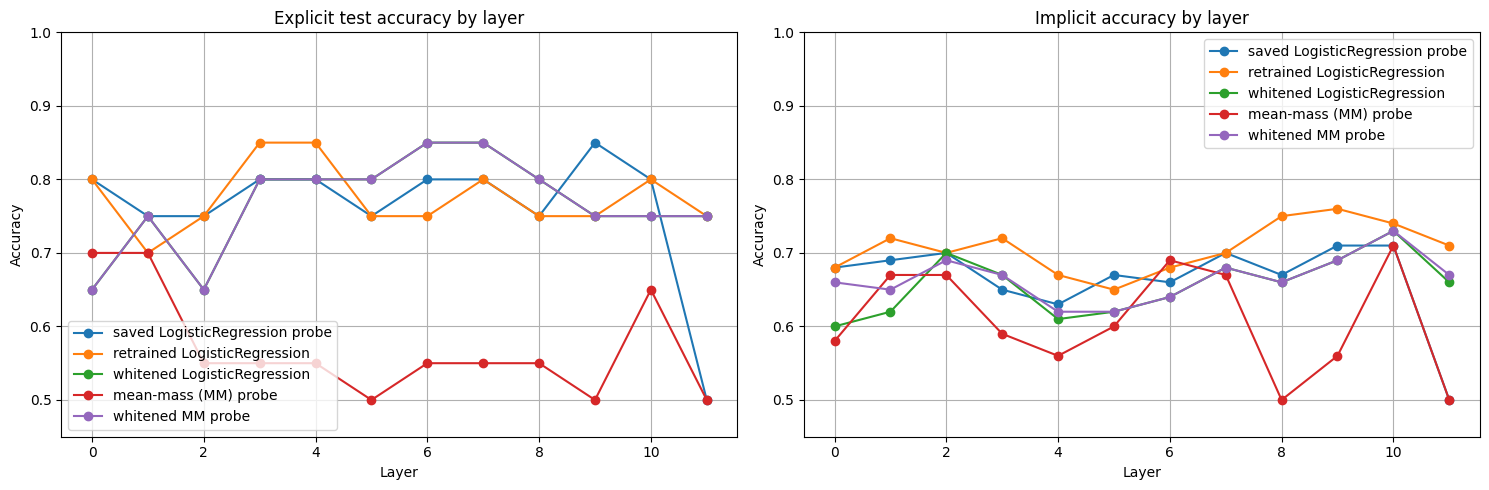

In [21]:
claimed_train_peak_layer = 8
claimed_train_peak_acc = 0.925
claimed_test_peak_layer = 6
claimed_test_peak_acc = 0.84

actual_saved_l8 = float(saved_eval_df.loc[saved_eval_df.layer == claimed_train_peak_layer, 'saved_probe_explicit_test_acc'].iloc[0])
actual_saved_l6 = float(saved_eval_df.loc[saved_eval_df.layer == claimed_test_peak_layer, 'saved_probe_implicit_acc'].iloc[0])

print('Claimed (repo README):')
print('  Layer 8 train/explicit peak ~', claimed_train_peak_acc)
print('  Layer 6 test/implicit ~', claimed_test_peak_acc)
print('\nMeasured with saved probes on current dataset files:')
print('  Layer 8 explicit test acc =', round(actual_saved_l8, 4))
print('  Layer 6 implicit acc      =', round(actual_saved_l6, 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5.0))

# Explicit test split
ax[0].plot(saved_eval_df.layer, saved_eval_df.saved_probe_explicit_test_acc, marker='o', label='saved LogisticRegression probe')
ax[0].plot(retrain_df.layer, retrain_df.retrained_explicit_test_acc, marker='o', label='retrained LogisticRegression')
ax[0].plot(wlr_df.layer, wlr_df.wlr_explicit_test_acc, marker='o', label='whitened LogisticRegression')
ax[0].plot(mm_df.layer, mm_df.mm_explicit_test_acc, marker='o', label='mean-mass (MM) probe')
ax[0].plot(wmm_df.layer, wmm_df.wmm_explicit_test_acc, marker='o', label='whitened MM probe')
# ax[0].axhline(claimed_train_peak_acc, linestyle='--', color='gray', label='claimed 0.925')
ax[0].set_title('Explicit test accuracy by layer')
ax[0].set_xlabel('Layer')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.45, 1.0)
ax[0].grid()
ax[0].legend(loc='lower left')

# Implicit dataset
ax[1].plot(saved_eval_df.layer, saved_eval_df.saved_probe_implicit_acc, marker='o', label='saved LogisticRegression probe')
ax[1].plot(retrain_df.layer, retrain_df.retrained_implicit_acc, marker='o', label='retrained LogisticRegression')
ax[1].plot(wlr_df.layer, wlr_df.wlr_implicit_acc, marker='o', label='whitened LogisticRegression')
ax[1].plot(mm_df.layer, mm_df.mm_implicit_acc, marker='o', label='mean-mass (MM) probe')
ax[1].plot(wmm_df.layer, wmm_df.wmm_implicit_acc, marker='o', label='whitened MM probe')
# ax[1].axhline(claimed_test_peak_acc, linestyle='--', color='gray', label='claimed 0.84')
ax[1].set_title('Implicit accuracy by layer')
ax[1].set_xlabel('Layer')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.45, 1.0)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()



## Expanded Dataset Evaluation (500 explicit / 300 implicit)

This section repeats the same methodology as above on:
- `temporal_scope_explicit_expanded_500.json`
- `temporal_scope_implicit_expanded_300.json`

Methodology matches the main section:
- same GPT-2 activation extraction (`last-token` per layer),
- same train/test split on explicit prompts (`test_size=0.2`, `random_state=42`, `stratify=y`),
- same probe variants (saved LR checkpoints, retrained LR, whitened LR, MM, whitened MM),
- same style of final layer-wise accuracy plots.


Expanded explicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json
Expanded implicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json
Expanded explicit metadata: {'dimension': 'temporal_scope', 'style': 'explicit_markers', 'description': '500 high-quality explicit temporal scope pairs WITH temporal words. Designed for training temporal horizon detection.', 'n_pairs': 500, 'validation': 'Pre-validated for temporal keyword presence, structural balance, and clear temporal distinction', 'created': '2025-02-01', 'version': '1.0', 'categories': ['planning', 'decision_making', 'problem_solving', 'investment', 'priorities', 'thinking', 'tradeoffs', 'goals', 'action', 'vision', 'risk_management', 'resource_allocation', 'strategy_formation', 'change_management', 'innovation', 'leadership', 'communication', 'evaluation'

,dataset,path,sha256
0,explicit_expanded_500,data/raw/temporal_scope_AB_randomized/temporal...,f5b24f59ba37a19cd2b6dcdd381fee04b3b68d4800ae19...
1,implicit_expanded_300,data/raw/temporal_scope_AB_randomized/temporal...,52a366046f83bc22e9cc242a1f01221f09693040cd347e...


Expanded explicit samples: 1000 | class balance: [500 500]
Expanded implicit samples: 600 | class balance: [300 300]
Expanded activation shapes:
  explicit layer 0: (1000, 768)
  implicit layer 0: (600, 768)


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc
0,0,0.780,0.735,0.655000
1,1,0.770,0.738,0.628333
2,2,0.760,0.720,0.610000
3,3,0.815,0.766,0.631667
4,4,0.835,0.779,0.658333
5,5,0.810,0.783,0.660000
6,6,0.800,0.774,0.695000
7,7,0.790,0.773,0.720000
8,8,0.765,0.780,0.716667
9,9,0.785,0.785,0.715000


/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_67850/2272446877.py:150: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_67850/2272446877.py:150: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_67850/2272446877.py:150: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_67850/2272446877.py:150: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. 

...

,layer,mm_explicit_test_acc,mm_implicit_acc,mm_direction_norm
0,0,0.650,0.551667,9.788283
1,1,0.685,0.566667,11.339445
2,2,0.800,0.603333,13.003221
3,3,0.825,0.561667,15.441221
4,4,0.895,0.593333,17.398178
5,5,0.830,0.553333,19.430822
6,6,0.875,0.643333,21.814478
7,7,0.855,0.658333,24.425234
8,8,0.830,0.578333,27.522390
9,9,0.800,0.570000,30.845194


,layer,wmm_explicit_test_acc,wmm_implicit_acc,wmm_effective_direction_norm,wmm_cov_reg_condition_number,wmm_reg
0,0,0.870,0.613333,2.987283,7866.286888,0.01
1,1,0.895,0.681667,2.661534,8640.715580,0.01
2,2,0.905,0.680000,2.139297,9136.438246,0.01
3,3,0.945,0.736667,1.683893,9338.878912,0.01
4,4,0.925,0.698333,1.485463,9855.934562,0.01
5,5,0.935,0.705000,1.350230,10209.239692,0.01
6,6,0.945,0.680000,1.198394,10250.311075,0.01
7,7,0.960,0.691667,1.119378,10256.456120,0.01
8,8,0.960,0.645000,1.012415,10305.843618,0.01
9,9,0.945,0.673333,0.897941,9495.648892,0.01


,layer,cosine_lr_vs_mm,cosine_lr_vs_wmm
0,0,0.299478,0.716137
1,1,0.321492,0.683824
2,2,0.411057,0.615610
3,3,0.435186,0.590665
4,4,0.474872,0.543256
5,5,0.475879,0.531907
6,6,0.506693,0.515150
7,7,0.490589,0.507725
8,8,0.490269,0.492033
9,9,0.504246,0.469608


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc,retrained_explicit_test_acc,retrained_implicit_acc,wlr_explicit_test_acc,wlr_implicit_acc,mm_explicit_test_acc,mm_implicit_acc,wmm_explicit_test_acc,wmm_implicit_acc
0,0,0.780,0.735,0.655000,0.875,0.663333,0.850,0.570000,0.650,0.551667,0.870,0.613333
1,1,0.770,0.738,0.628333,0.920,0.691667,0.820,0.671667,0.685,0.566667,0.895,0.681667
2,2,0.760,0.720,0.610000,0.915,0.725000,0.905,0.666667,0.800,0.603333,0.905,0.680000
3,3,0.815,0.766,0.631667,0.940,0.751667,0.895,0.666667,0.825,0.561667,0.945,0.736667
4,4,0.835,0.779,0.658333,0.965,0.743333,0.880,0.658333,0.895,0.593333,0.925,0.698333
5,5,0.810,0.783,0.660000,0.960,0.735000,0.910,0.633333,0.830,0.553333,0.935,0.705000
6,6,0.800,0.774,0.695000,0.945,0.783333,0.900,0.645000,0.875,0.643333,0.945,0.680000
7,7,0.790,0.773,0.720000,0.965,0.801667,0.945,0.643333,0.855,0.658333,0.960,0.691667
8,8,0.765,0.780,0.716667,0.960,0.773333,0.900,0.620000,0.830,0.578333,0.960,0.645000
9,9,0.785,0.785,0.715000,0.960,0.801667,0.895,0.646667,0.800,0.570000,0.945,0.673333


Expanded best saved-probe explicit TEST layer: 4 acc= 0.835
Expanded best saved-probe implicit layer: 7 acc= 0.72
Expanded best LR explicit TEST layer: 4 acc= 0.965
Expanded best LR implicit layer: 10 acc= 0.83
Expanded best WLR explicit TEST layer: 7 acc= 0.945
Expanded best WLR implicit layer: 11 acc= 0.7517
Expanded best MM explicit TEST layer:  4 acc= 0.895
Expanded best MM implicit layer:  10 acc= 0.6883
Expanded best WMM explicit TEST layer: 11 acc= 0.97
Expanded best WMM implicit layer: 11 acc= 0.7767


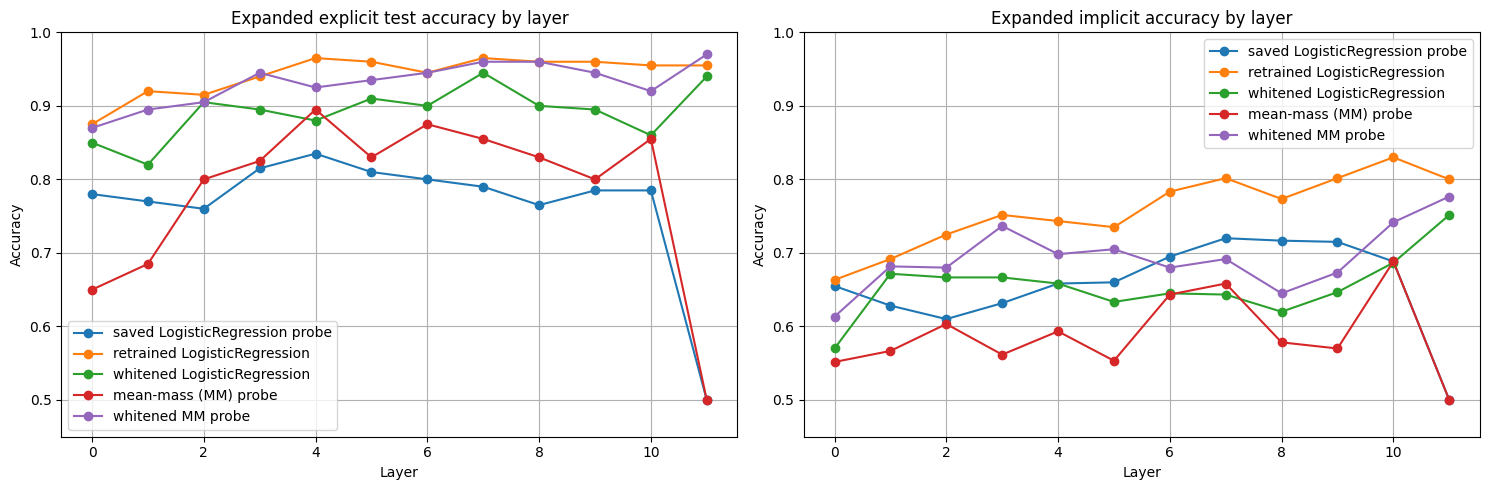

In [22]:
# Resolve expanded dataset files
explicit_expanded_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_explicit_expanded_500.json',
    ROOT / 'data/raw/temporal_scope_explicit_expanded_500.json',
])
implicit_expanded_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_implicit_expanded_300.json',
    ROOT / 'data/raw/temporal_scope_implicit_expanded_300.json',
])

expd_meta, explicit_pairs_expd = load_pairs(explicit_expanded_path)
impd_meta, implicit_pairs_expd = load_pairs(implicit_expanded_path)

print('Expanded explicit dataset:', explicit_expanded_path)
print('Expanded implicit dataset:', implicit_expanded_path)
print('Expanded explicit metadata:', expd_meta)
print('Expanded implicit metadata:', impd_meta)
print('Expanded counts: explicit pairs =', len(explicit_pairs_expd), '| implicit pairs =', len(implicit_pairs_expd))

expanded_hash_df = pd.DataFrame([
    {
        'dataset': 'explicit_expanded_500',
        'path': str(explicit_expanded_path.relative_to(ROOT)),
        'sha256': sha256(explicit_expanded_path),
    },
    {
        'dataset': 'implicit_expanded_300',
        'path': str(implicit_expanded_path.relative_to(ROOT)),
        'sha256': sha256(implicit_expanded_path),
    },
])
display(expanded_hash_df)

# Build expanded prompt-level datasets
explicit_prompts_expd, y_exp_expd = build_prompts_and_labels(explicit_pairs_expd)
implicit_prompts_expd, y_imp_expd = build_prompts_and_labels(implicit_pairs_expd)

print('Expanded explicit samples:', len(y_exp_expd), '| class balance:', np.bincount(y_exp_expd))
print('Expanded implicit samples:', len(y_imp_expd), '| class balance:', np.bincount(y_imp_expd))

# Extract activations
X_exp_expd = extract_last_token_activations(explicit_prompts_expd, batch_size=16)
X_imp_expd = extract_last_token_activations(implicit_prompts_expd, batch_size=16)

print('Expanded activation shapes:')
print('  explicit layer 0:', X_exp_expd[0].shape)
print('  implicit layer 0:', X_imp_expd[0].shape)

# Same split recipe as base section
indices_expd = np.arange(len(y_exp_expd))
train_idx_expd, test_idx_expd = train_test_split(
    indices_expd,
    test_size=0.2,
    random_state=42,
    stratify=y_exp_expd,
)

# Evaluate saved checkpoints on expanded datasets
rows_expd = []
for layer in range(n_layers):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        probe = pickle.load(open(probe_paths[layer], 'rb'))

    rows_expd.append({
        'layer': layer,
        'saved_probe_explicit_test_acc': probe.score(X_exp_expd[layer][test_idx_expd], y_exp_expd[test_idx_expd]),
        'saved_probe_explicit_full_acc': probe.score(X_exp_expd[layer], y_exp_expd),
        'saved_probe_implicit_acc': probe.score(X_imp_expd[layer], y_imp_expd),
    })

saved_eval_df_expd = pd.DataFrame(rows_expd).sort_values('layer').reset_index(drop=True)
display(saved_eval_df_expd)

# Retrain probes on expanded explicit train split, evaluate on expanded explicit test + full expanded implicit
retrain_rows_expd = []
wlr_rows_expd = []
mm_rows_expd = []
wmm_rows_expd = []
cosine_rows_expd = []
mm_probe_checkpoints_expd = []

for layer in range(n_layers):
    X_train = X_exp_expd[layer][train_idx_expd]
    y_train = y_exp_expd[train_idx_expd]
    X_test = X_exp_expd[layer][test_idx_expd]
    y_test = y_exp_expd[test_idx_expd]

    # LogisticRegression probe (raw activations)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    retrain_rows_expd.append({
        'layer': layer,
        'retrained_explicit_test_acc': clf.score(X_test, y_test),
        'retrained_implicit_acc': clf.score(X_imp_expd[layer], y_imp_expd),
    })

    # Whitened LogisticRegression probe
    whitener = fit_whitener(X_train, reg=whiten_reg)
    X_train_w = apply_whitener(X_train, whitener)
    X_test_w = apply_whitener(X_test, whitener)
    X_imp_w = apply_whitener(X_imp_expd[layer], whitener)

    clf_w = LogisticRegression(max_iter=1000, random_state=42)
    clf_w.fit(X_train_w, y_train)
    wlr_rows_expd.append({
        'layer': layer,
        'wlr_explicit_test_acc': clf_w.score(X_test_w, y_test),
        'wlr_implicit_acc': clf_w.score(X_imp_w, y_imp_expd),
        'wlr_cov_reg_condition_number': whitener['cov_reg_condition_number'],
        'wlr_reg': float(whiten_reg),
    })

    # Mean-mass (difference-in-means) probe
    mm_direction = train_mm_probe(X_train, y_train)
    mm_pred_test, _ = mm_predict(X_test, mm_direction)
    mm_pred_implicit, _ = mm_predict(X_imp_expd[layer], mm_direction)

    mm_rows_expd.append({
        'layer': layer,
        'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
        'mm_implicit_acc': float((mm_pred_implicit == y_imp_expd).mean()),
        'mm_direction_norm': float(np.linalg.norm(mm_direction)),
    })

    mm_train_scores = X_train @ mm_direction
    mm_score_scale = float(np.std(mm_train_scores))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = float(np.mean(np.abs(mm_train_scores)))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = 1.0

    mm_probe_checkpoints_expd.append({
        'probe_type': 'mean_mass',
        'model_name': MODEL_NAME,
        'layer': int(layer),
        'explicit_dataset_path': str(explicit_expanded_path),
        'n_pairs': int(len(explicit_pairs_expd)),
        'n_samples': int(len(y_exp_expd)),
        'train_size': int(len(train_idx_expd)),
        'test_size': int(len(test_idx_expd)),
        'train_accuracy': float(((mm_train_scores > 0).astype(np.int64) == y_train).mean()),
        'test_accuracy': float((mm_pred_test == y_test).mean()),
        'direction_norm': float(np.linalg.norm(mm_direction)),
        'score_scale': mm_score_scale,
        'random_state': 42,
        'device': str(device),
        'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
        'direction': mm_direction.astype(np.float32).tolist(),
    })

    # Whitened MM probe
    wmm_model = train_whitened_mm_probe(X_train, y_train, reg=whiten_reg)
    wmm_pred_test, _ = whitened_mm_predict(X_test, wmm_model)
    wmm_pred_implicit, _ = whitened_mm_predict(X_imp_expd[layer], wmm_model)

    wmm_rows_expd.append({
        'layer': layer,
        'wmm_explicit_test_acc': float((wmm_pred_test == y_test).mean()),
        'wmm_implicit_acc': float((wmm_pred_implicit == y_imp_expd).mean()),
        'wmm_effective_direction_norm': float(np.linalg.norm(wmm_model['effective_direction'])),
        'wmm_cov_reg_condition_number': wmm_model['cov_reg_condition_number'],
        'wmm_reg': float(whiten_reg),
    })

    # Geometry comparisons
    w_lr = clf.coef_.ravel()
    eff_dir = wmm_model['effective_direction']

    denom_mm = (np.linalg.norm(w_lr) * np.linalg.norm(mm_direction)) + 1e-12
    denom_wmm = (np.linalg.norm(w_lr) * np.linalg.norm(eff_dir)) + 1e-12
    cos_lr_vs_mm = float(np.dot(w_lr, mm_direction) / denom_mm)
    cos_lr_vs_wmm = float(np.dot(w_lr, eff_dir) / denom_wmm)

    cosine_rows_expd.append({
        'layer': layer,
        'cosine_lr_vs_mm': cos_lr_vs_mm,
        'cosine_lr_vs_wmm': cos_lr_vs_wmm,
    })

mm_probe_checkpoint_rows_expd = []
for checkpoint in mm_probe_checkpoints_expd:
    checkpoint_path = probe_dir / f"mmraz_gpt2_explicit_expanded_mm_probe_layer_{checkpoint['layer']}.json"
    checkpoint_path.write_text(json.dumps(checkpoint, indent=2) + '\n', encoding='utf-8')
    mm_probe_checkpoint_rows_expd.append({
        'layer': checkpoint['layer'],
        'checkpoint_path': str(checkpoint_path.relative_to(ROOT)),
        'test_accuracy': checkpoint['test_accuracy'],
        'score_scale': checkpoint['score_scale'],
    })

mm_probe_checkpoint_df_expd = pd.DataFrame(mm_probe_checkpoint_rows_expd).sort_values('layer').reset_index(drop=True)
display(mm_probe_checkpoint_df_expd)
print('Saved expanded GPT-2 MM probe checkpoints to', probe_dir)

retrain_df_expd = pd.DataFrame(retrain_rows_expd).sort_values('layer').reset_index(drop=True)
wlr_df_expd = pd.DataFrame(wlr_rows_expd).sort_values('layer').reset_index(drop=True)
mm_df_expd = pd.DataFrame(mm_rows_expd).sort_values('layer').reset_index(drop=True)
wmm_df_expd = pd.DataFrame(wmm_rows_expd).sort_values('layer').reset_index(drop=True)
cosine_df_expd = pd.DataFrame(cosine_rows_expd).sort_values('layer').reset_index(drop=True)

display(retrain_df_expd)
display(wlr_df_expd)
display(mm_df_expd)
display(wmm_df_expd)
display(cosine_df_expd)

comparison_expd = (
    saved_eval_df_expd
    .merge(retrain_df_expd, on='layer', how='inner')
    .merge(wlr_df_expd[['layer', 'wlr_explicit_test_acc', 'wlr_implicit_acc']], on='layer', how='inner')
    .merge(mm_df_expd[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']], on='layer', how='inner')
    .merge(wmm_df_expd[['layer', 'wmm_explicit_test_acc', 'wmm_implicit_acc']], on='layer', how='inner')
)
display(comparison_expd)

best_saved_exp_expd = saved_eval_df_expd.loc[saved_eval_df_expd['saved_probe_explicit_test_acc'].idxmax()]
best_saved_imp_expd = saved_eval_df_expd.loc[saved_eval_df_expd['saved_probe_implicit_acc'].idxmax()]
print('Expanded best saved-probe explicit TEST layer:', int(best_saved_exp_expd.layer), 'acc=', round(float(best_saved_exp_expd.saved_probe_explicit_test_acc), 4))
print('Expanded best saved-probe implicit layer:', int(best_saved_imp_expd.layer), 'acc=', round(float(best_saved_imp_expd.saved_probe_implicit_acc), 4))

best_lr_exp_expd = retrain_df_expd.loc[retrain_df_expd['retrained_explicit_test_acc'].idxmax()]
best_lr_imp_expd = retrain_df_expd.loc[retrain_df_expd['retrained_implicit_acc'].idxmax()]
best_wlr_exp_expd = wlr_df_expd.loc[wlr_df_expd['wlr_explicit_test_acc'].idxmax()]
best_wlr_imp_expd = wlr_df_expd.loc[wlr_df_expd['wlr_implicit_acc'].idxmax()]
best_mm_exp_expd = mm_df_expd.loc[mm_df_expd['mm_explicit_test_acc'].idxmax()]
best_mm_imp_expd = mm_df_expd.loc[mm_df_expd['mm_implicit_acc'].idxmax()]
best_wmm_exp_expd = wmm_df_expd.loc[wmm_df_expd['wmm_explicit_test_acc'].idxmax()]
best_wmm_imp_expd = wmm_df_expd.loc[wmm_df_expd['wmm_implicit_acc'].idxmax()]

print('Expanded best LR explicit TEST layer:', int(best_lr_exp_expd.layer), 'acc=', round(float(best_lr_exp_expd.retrained_explicit_test_acc), 4))
print('Expanded best LR implicit layer:', int(best_lr_imp_expd.layer), 'acc=', round(float(best_lr_imp_expd.retrained_implicit_acc), 4))
print('Expanded best WLR explicit TEST layer:', int(best_wlr_exp_expd.layer), 'acc=', round(float(best_wlr_exp_expd.wlr_explicit_test_acc), 4))
print('Expanded best WLR implicit layer:', int(best_wlr_imp_expd.layer), 'acc=', round(float(best_wlr_imp_expd.wlr_implicit_acc), 4))
print('Expanded best MM explicit TEST layer: ', int(best_mm_exp_expd.layer), 'acc=', round(float(best_mm_exp_expd.mm_explicit_test_acc), 4))
print('Expanded best MM implicit layer: ', int(best_mm_imp_expd.layer), 'acc=', round(float(best_mm_imp_expd.mm_implicit_acc), 4))
print('Expanded best WMM explicit TEST layer:', int(best_wmm_exp_expd.layer), 'acc=', round(float(best_wmm_exp_expd.wmm_explicit_test_acc), 4))
print('Expanded best WMM implicit layer:', int(best_wmm_imp_expd.layer), 'acc=', round(float(best_wmm_imp_expd.wmm_implicit_acc), 4))

# Same final plot style as the main section
fig, ax = plt.subplots(1, 2, figsize=(15, 5.0))

# Explicit test split
ax[0].plot(saved_eval_df_expd.layer, saved_eval_df_expd.saved_probe_explicit_test_acc, marker='o', label='saved LogisticRegression probe')
ax[0].plot(retrain_df_expd.layer, retrain_df_expd.retrained_explicit_test_acc, marker='o', label='retrained LogisticRegression')
ax[0].plot(wlr_df_expd.layer, wlr_df_expd.wlr_explicit_test_acc, marker='o', label='whitened LogisticRegression')
ax[0].plot(mm_df_expd.layer, mm_df_expd.mm_explicit_test_acc, marker='o', label='mean-mass (MM) probe')
ax[0].plot(wmm_df_expd.layer, wmm_df_expd.wmm_explicit_test_acc, marker='o', label='whitened MM probe')
ax[0].set_title('Expanded explicit test accuracy by layer')
ax[0].set_xlabel('Layer')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.45, 1.0)
ax[0].grid()
ax[0].legend()

# Implicit dataset
ax[1].plot(saved_eval_df_expd.layer, saved_eval_df_expd.saved_probe_implicit_acc, marker='o', label='saved LogisticRegression probe')
ax[1].plot(retrain_df_expd.layer, retrain_df_expd.retrained_implicit_acc, marker='o', label='retrained LogisticRegression')
ax[1].plot(wlr_df_expd.layer, wlr_df_expd.wlr_implicit_acc, marker='o', label='whitened LogisticRegression')
ax[1].plot(mm_df_expd.layer, mm_df_expd.mm_implicit_acc, marker='o', label='mean-mass (MM) probe')
ax[1].plot(wmm_df_expd.layer, wmm_df_expd.wmm_implicit_acc, marker='o', label='whitened MM probe')
ax[1].set_title('Expanded implicit accuracy by layer')
ax[1].set_xlabel('Layer')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.45, 1.0)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()


In [23]:
# Serialize all fitted probe families so they can be reused outside the notebook.
PROBE_FORMAT_SLUG = 'choices_single_option_last_token'
BASE_PROBE_DIR = ROOT / 'results/checkpoints' / ('mmraz_probe_variations_base_' + PROBE_FORMAT_SLUG)
EXPANDED_PROBE_DIR = ROOT / 'results/checkpoints' / ('mmraz_probe_variations_expanded_' + PROBE_FORMAT_SLUG)
BASE_PREFIX = 'mmraz_gpt2_base_choices_last_token'
EXPANDED_PREFIX = 'mmraz_gpt2_expanded_choices_last_token'
EXPANDED_MM_FILENAME_TEMPLATE = 'mmraz_gpt2_explicit_expanded_mm_probe_layer_{layer}.json'

for checkpoint_dir in [BASE_PROBE_DIR, EXPANDED_PROBE_DIR]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)


def relative_to_root(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)



def write_json(path, payload):
    Path(path).write_text(json.dumps(payload, indent=2) + '\n', encoding='utf-8')



def compute_score_scale(scores):
    score_scale = float(np.std(scores))
    if (not np.isfinite(score_scale)) or score_scale <= 1e-8:
        score_scale = float(np.mean(np.abs(scores)))
    if (not np.isfinite(score_scale)) or score_scale <= 1e-8:
        score_scale = 1.0
    return score_scale



def save_whitener_artifact(dir_path, prefix, layer, whitener, metadata):
    arrays_path = dir_path / f'{prefix}_whitener_layer_{layer}.npz'
    np.savez_compressed(
        arrays_path,
        mean_train=np.asarray(whitener['mean_train'], dtype=np.float32),
        inv_sqrt=np.asarray(whitener['inv_sqrt'], dtype=np.float32),
    )

    metadata_path = dir_path / f'{prefix}_whitener_layer_{layer}.json'
    metadata_payload = {
        **metadata,
        'artifact_type': 'whitener',
        'transform_type': 'center_then_right_multiply_inv_sqrt',
        'mean_shape': list(np.asarray(whitener['mean_train']).shape),
        'inv_sqrt_shape': list(np.asarray(whitener['inv_sqrt']).shape),
        'reg': float(whitener['reg']),
        'cov_reg_condition_number': float(whitener['cov_reg_condition_number']),
        'array_path': relative_to_root(arrays_path),
    }
    write_json(metadata_path, metadata_payload)
    return metadata_path, arrays_path



def save_probe_suite(
    dir_path,
    prefix,
    train_dataset,
    train_layers,
    y_train,
    test_layers,
    y_test,
    implicit_layers,
    y_implicit,
    dataset_metadata,
    mm_filename_template=None,
):
    dir_path = Path(dir_path)
    dir_path.mkdir(parents=True, exist_ok=True)

    metrics_rows = []
    artifact_rows = []

    for layer in range(n_layers):
        X_train = np.asarray(train_layers[layer], dtype=np.float32)
        X_test = np.asarray(test_layers[layer], dtype=np.float32)
        X_implicit = np.asarray(implicit_layers[layer], dtype=np.float32)

        common_metadata = {
            'model_name': MODEL_NAME,
            'layer': int(layer),
            'train_dataset': train_dataset,
            'probe_format': PROBE_FORMAT_SLUG,
            'activation_pooling': 'last_non_padding_token',
            'option_labels_stripped': False,
            'train_size': int(len(y_train)),
            'test_size': int(len(y_test)),
            'implicit_size': int(len(y_implicit)),
            'random_state': 42,
            'device': str(device),
            **dataset_metadata,
        }

        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train, y_train)
        lr_train_acc = float(clf.score(X_train, y_train))
        lr_test_acc = float(clf.score(X_test, y_test))
        lr_implicit_acc = float(clf.score(X_implicit, y_implicit))
        lr_path = dir_path / f'{prefix}_lr_probe_layer_{layer}.json'
        write_json(lr_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'raw',
            'train_accuracy': lr_train_acc,
            'test_accuracy': lr_test_acc,
            'implicit_accuracy': lr_implicit_acc,
            'coef': clf.coef_.astype(np.float32).ravel().tolist(),
            'intercept': float(clf.intercept_[0]),
            'classes': [int(v) for v in clf.classes_.tolist()],
            'n_iter': int(np.asarray(clf.n_iter_).ravel()[0]),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'raw',
            'json_path': relative_to_root(lr_path),
            'array_path': '',
        })

        whitener = fit_whitener(X_train, reg=whiten_reg)
        whitener_metadata_path, whitener_arrays_path = save_whitener_artifact(
            dir_path,
            prefix,
            layer,
            whitener,
            common_metadata,
        )
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'whitener',
            'probe_type': 'shared_whitener',
            'feature_space': 'raw_to_whitened',
            'json_path': relative_to_root(whitener_metadata_path),
            'array_path': relative_to_root(whitener_arrays_path),
        })

        X_train_w = apply_whitener(X_train, whitener)
        X_test_w = apply_whitener(X_test, whitener)
        X_implicit_w = apply_whitener(X_implicit, whitener)

        clf_w = LogisticRegression(max_iter=1000, random_state=42)
        clf_w.fit(X_train_w, y_train)
        wlr_train_acc = float(clf_w.score(X_train_w, y_train))
        wlr_test_acc = float(clf_w.score(X_test_w, y_test))
        wlr_implicit_acc = float(clf_w.score(X_implicit_w, y_implicit))
        wlr_path = dir_path / f'{prefix}_wlr_probe_layer_{layer}.json'
        write_json(wlr_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'whitened',
            'train_accuracy': wlr_train_acc,
            'test_accuracy': wlr_test_acc,
            'implicit_accuracy': wlr_implicit_acc,
            'coef': clf_w.coef_.astype(np.float32).ravel().tolist(),
            'intercept': float(clf_w.intercept_[0]),
            'classes': [int(v) for v in clf_w.classes_.tolist()],
            'n_iter': int(np.asarray(clf_w.n_iter_).ravel()[0]),
            'whitener_metadata_path': relative_to_root(whitener_metadata_path),
            'whitener_array_path': relative_to_root(whitener_arrays_path),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'whitened',
            'json_path': relative_to_root(wlr_path),
            'array_path': '',
        })

        mm_direction = train_mm_probe(X_train, y_train).astype(np.float32)
        mm_train_pred, mm_train_scores = mm_predict(X_train, mm_direction)
        mm_pred_test, _ = mm_predict(X_test, mm_direction)
        mm_pred_implicit, _ = mm_predict(X_implicit, mm_direction)
        mm_score_scale = compute_score_scale(mm_train_scores)
        if mm_filename_template is None:
            mm_path = dir_path / f'{prefix}_mm_probe_layer_{layer}.json'
        else:
            mm_path = dir_path / mm_filename_template.format(layer=layer)
        write_json(mm_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'raw',
            'train_accuracy': float((mm_train_pred == y_train).mean()),
            'test_accuracy': float((mm_pred_test == y_test).mean()),
            'implicit_accuracy': float((mm_pred_implicit == y_implicit).mean()),
            'direction_norm': float(np.linalg.norm(mm_direction)),
            'score_scale': mm_score_scale,
            'direction': mm_direction.tolist(),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'raw',
            'json_path': relative_to_root(mm_path),
            'array_path': '',
        })

        whitened_mm_direction = (np.asarray(whitener['inv_sqrt']) @ mm_direction).astype(np.float32)
        wmm_train_scores = X_train_w @ whitened_mm_direction
        wmm_test_scores = X_test_w @ whitened_mm_direction
        wmm_implicit_scores = X_implicit_w @ whitened_mm_direction
        wmm_path = dir_path / f'{prefix}_wmm_probe_layer_{layer}.json'
        write_json(wmm_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'whitened',
            'score_rule': 'score = ((x - mean_train) @ inv_sqrt) dot probe_direction',
            'train_accuracy': float(((wmm_train_scores > 0).astype(np.int64) == y_train).mean()),
            'test_accuracy': float(((wmm_test_scores > 0).astype(np.int64) == y_test).mean()),
            'implicit_accuracy': float(((wmm_implicit_scores > 0).astype(np.int64) == y_implicit).mean()),
            'probe_direction_norm': float(np.linalg.norm(whitened_mm_direction)),
            'score_scale': compute_score_scale(wmm_train_scores),
            'probe_direction': whitened_mm_direction.tolist(),
            'raw_mm_direction': mm_direction.tolist(),
            'whitener_metadata_path': relative_to_root(whitener_metadata_path),
            'whitener_array_path': relative_to_root(whitener_arrays_path),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'whitened',
            'json_path': relative_to_root(wmm_path),
            'array_path': '',
        })

        metrics_rows.append({
            'layer': int(layer),
            'train_dataset': train_dataset,
            'lr_train_acc': lr_train_acc,
            'lr_explicit_test_acc': lr_test_acc,
            'lr_implicit_acc': lr_implicit_acc,
            'wlr_train_acc': wlr_train_acc,
            'wlr_explicit_test_acc': wlr_test_acc,
            'wlr_implicit_acc': wlr_implicit_acc,
            'mm_train_acc': float((mm_train_pred == y_train).mean()),
            'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
            'mm_implicit_acc': float((mm_pred_implicit == y_implicit).mean()),
            'mm_direction_norm': float(np.linalg.norm(mm_direction)),
            'wmm_train_acc': float(((wmm_train_scores > 0).astype(np.int64) == y_train).mean()),
            'wmm_explicit_test_acc': float(((wmm_test_scores > 0).astype(np.int64) == y_test).mean()),
            'wmm_implicit_acc': float(((wmm_implicit_scores > 0).astype(np.int64) == y_implicit).mean()),
            'wmm_probe_direction_norm': float(np.linalg.norm(whitened_mm_direction)),
            'whitener_reg': float(whitener['reg']),
            'whitener_cov_reg_condition_number': float(whitener['cov_reg_condition_number']),
        })

    metrics_df = pd.DataFrame(metrics_rows).sort_values('layer').reset_index(drop=True)
    artifact_df = pd.DataFrame(artifact_rows).sort_values(['layer', 'artifact_type', 'probe_type', 'feature_space']).reset_index(drop=True)
    metrics_path = dir_path / f'{prefix}_metrics_by_layer.csv'
    artifact_index_path = dir_path / f'{prefix}_artifact_index.csv'
    metrics_df.to_csv(metrics_path, index=False)
    artifact_df.to_csv(artifact_index_path, index=False)
    metrics_df.attrs['metrics_path'] = str(metrics_path)
    artifact_df.attrs['artifact_index_path'] = str(artifact_index_path)
    print('Saved probe suite:', dir_path)
    print('  metrics:', metrics_path)
    print('  artifact index:', artifact_index_path)
    return metrics_df, artifact_df


suite_results = {}
suite_results['base_explicit_only'] = save_probe_suite(
    dir_path=BASE_PROBE_DIR,
    prefix=BASE_PREFIX,
    train_dataset='base_explicit_only',
    train_layers=[X_exp[layer][train_idx] for layer in range(n_layers)],
    y_train=y_exp[train_idx],
    test_layers=[X_exp[layer][test_idx] for layer in range(n_layers)],
    y_test=y_exp[test_idx],
    implicit_layers=X_imp,
    y_implicit=y_imp,
    dataset_metadata={
        'explicit_dataset_path': str(explicit_path),
        'implicit_dataset_path': str(implicit_path),
    },
)
suite_results['expanded_explicit_only'] = save_probe_suite(
    dir_path=EXPANDED_PROBE_DIR,
    prefix=EXPANDED_PREFIX,
    train_dataset='expanded_explicit_only',
    train_layers=[X_exp_expd[layer][train_idx_expd] for layer in range(n_layers)],
    y_train=y_exp_expd[train_idx_expd],
    test_layers=[X_exp_expd[layer][test_idx_expd] for layer in range(n_layers)],
    y_test=y_exp_expd[test_idx_expd],
    implicit_layers=X_imp_expd,
    y_implicit=y_imp_expd,
    dataset_metadata={
        'explicit_dataset_path': str(explicit_expanded_path),
        'implicit_dataset_path': str(implicit_expanded_path),
        'n_pairs': int(len(explicit_pairs_expd)),
    },
    mm_filename_template=EXPANDED_MM_FILENAME_TEMPLATE,
)

storage_overview_df = pd.DataFrame([
    {
        'suite': key,
        'metrics_path': relative_to_root(result[0].attrs['metrics_path']),
        'artifact_index_path': relative_to_root(result[1].attrs['artifact_index_path']),
        'artifact_count': int(len(result[1])),
    }
    for key, result in suite_results.items()
])

display(storage_overview_df)
display({key: value[0].head() for key, value in suite_results.items()})


Saved probe suite: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_choices_single_option_last_token
  metrics: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_choices_single_option_last_token/mmraz_gpt2_base_choices_last_token_metrics_by_layer.csv
  artifact index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_choices_single_option_last_token/mmraz_gpt2_base_choices_last_token_artifact_index.csv
Saved probe suite: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_expanded_choices_single_option_last_token
  metrics: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_expanded_choices_single_option_last_token/mmraz_gpt2_expanded_choices_last_token_metrics_by_layer.csv
  artifact index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/m

,suite,metrics_path,artifact_index_path,artifact_count
0,base_explicit_only,results/checkpoints/mmraz_probe_variations_bas...,results/checkpoints/mmraz_probe_variations_bas...,60
1,expanded_explicit_only,results/checkpoints/mmraz_probe_variations_exp...,results/checkpoints/mmraz_probe_variations_exp...,60


{'base_explicit_only':    layer       train_dataset  lr_train_acc  lr_explicit_test_acc  \
 0      0  base_explicit_only           1.0                  0.80   
 1      1  base_explicit_only           1.0                  0.70   
 2      2  base_explicit_only           1.0                  0.75   
 3      3  base_explicit_only           1.0                  0.85   
 4      4  base_explicit_only           1.0                  0.85   
 
    lr_implicit_acc  wlr_train_acc  wlr_explicit_test_acc  wlr_implicit_acc  \
 0             0.68            1.0                   0.65              0.60   
 1             0.72            1.0                   0.75              0.62   
 2             0.70            1.0                   0.65              0.70   
 3             0.72            1.0                   0.80              0.67   
 4             0.67            1.0                   0.80              0.61   
 
    mm_train_acc  mm_explicit_test_acc  mm_implicit_acc  mm_direction_norm  \
 0      